In [1]:
!pip install pandas numpy scikit-learn networkx scipy joblib matplotlib seaborn fastapi uvicorn


   ---------- ----------------------------- 1/4 [uvicorn]
   ---------- ----------------------------- 1/4 [uvicorn]
   -------------------- ------------------- 2/4 [starlette]
   -------------------- ------------------- 2/4 [starlette]
   ------------------------------ --------- 3/4 [fastapi]
   ------------------------------ --------- 3/4 [fastapi]
   ------------------------------ --------- 3/4 [fastapi]
   ---------------------------------------- 4/4 [fastapi]



In [2]:
import os
import json
import random
import warnings

from collections import defaultdict
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import networkx as nx

from scipy.sparse import coo_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")

RNG = 42

random.seed(RNG)
np.random.seed(RNG)

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
RAW_PATH = "delivery_data.csv"
ARTIFACT_DIR = "./artifacts"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

print("Current directory:", os.getcwd())
print("CSV exists:", os.path.exists(RAW_PATH))
print("Artifact directory:", ARTIFACT_DIR)

Current directory: C:\Users\Vineet Chauhan\project_del
CSV exists: True
Artifact directory: ./artifacts


In [5]:
print("STAGE 1: Loading dataset ...")

df = pd.read_csv(
    RAW_PATH,
    parse_dates=[
        "trip_creation_time",
        "od_start_time",
        "od_end_time",
        "cutoff_timestamp"
    ]
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

STAGE 1: Loading dataset ...
Dataset loaded successfully!
Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [6]:
print(df.columns.tolist())

['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor']


In [7]:
print("STAGE 1: Loading + aggregating to hop level ...")

df = df.sort_values("cutoff_factor")

hops = df.groupby(
    ["trip_uuid", "source_center", "destination_center"],
    as_index=False
).last()

hops = hops[hops["osrm_time"] > 0].copy()

print(f"Raw rows: {len(df):,}")
print(f"Hop-level rows: {len(hops):,}")

STAGE 1: Loading + aggregating to hop level ...
Raw rows: 144,867
Hop-level rows: 26,368


In [8]:
print("STAGE 2: Feature engineering ...")

hops["hour"] = hops["od_start_time"].dt.hour

hops["dayofweek"] = hops["od_start_time"].dt.dayofweek

hops["is_weekend"] = (
    hops["dayofweek"].isin([5, 6])
).astype(int)

hops["month"] = hops["od_start_time"].dt.month

hops["route_type_FTL"] = (
    hops["route_type"] == "FTL"
).astype(int)

print("Feature engineering completed.")

STAGE 2: Feature engineering ...
Feature engineering completed.


In [9]:
hops[
    [
        "hour",
        "dayofweek",
        "is_weekend",
        "month",
        "route_type",
        "route_type_FTL"
    ]
].head()

,hour,dayofweek,is_weekend,month,route_type,route_type_FTL
0,16,2,0,9,FTL,1
1,0,2,0,9,FTL,1
2,2,2,0,9,Carting,0
3,0,2,0,9,Carting,0
4,3,4,0,9,FTL,1


In [10]:
hops["delay_ratio"] = (
    hops["actual_time"] / hops["osrm_time"]
)

hops["sla_breach"] = (
    hops["delay_ratio"] > 1.20
).astype(int)

LEAKAGE_COLS = [
    "delay_ratio",
    "sla_breach",
    "actual_time"
]

print("Delay and SLA features created for auditing.")

Delay and SLA features created for auditing.


In [11]:
print("STAGE 3: Time-based train/test split ...")

hops = hops.sort_values(
    "trip_creation_time"
).reset_index(drop=True)

split_idx = int(len(hops) * 0.8)

train_hops = hops.iloc[:split_idx].copy()

test_hops = hops.iloc[split_idx:].copy()

split_date = hops["trip_creation_time"].iloc[split_idx]

print(f"Train rows: {len(train_hops):,}")
print(f"Test rows:  {len(test_hops):,}")
print(f"Split date: {split_date}")

STAGE 3: Time-based train/test split ...
Train rows: 21,094
Test rows:  5,274
Split date: 2018-09-28 23:13:07.007673


In [12]:
print("STAGE 4: Building delivery network graph ...")

G = nx.DiGraph()

edge_stats = (
    train_hops
    .groupby(
        ["source_center", "destination_center"]
    )
    .agg(
        median_delay_ratio=("delay_ratio", "median"),
        sla_breach_rate=("sla_breach", "mean"),
        trips=("trip_uuid", "count"),
        median_osrm_time=("osrm_time", "median")
    )
    .reset_index()
)

for _, r in edge_stats.iterrows():
    G.add_edge(
        r.source_center,
        r.destination_center,
        weight=r.median_delay_ratio,
        trips=r.trips,
        sla_breach_rate=r.sla_breach_rate
    )

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

STAGE 4: Building delivery network graph ...
Number of nodes: 1609
Number of edges: 2580


In [13]:
print("Calculating graph features ...")

btw = nx.betweenness_centrality(
    G,
    k=min(500, G.number_of_nodes()),
    seed=RNG,
    weight=None
)

pagerank = nx.pagerank(
    G,
    weight="weight"
)

indeg = dict(G.in_degree())

outdeg = dict(G.out_degree())

clustering = nx.clustering(
    G.to_undirected()
)

node_feats = pd.DataFrame({
    "node": list(G.nodes())
})

node_feats["betweenness"] = (
    node_feats["node"].map(btw)
)

node_feats["pagerank"] = (
    node_feats["node"].map(pagerank)
)

node_feats["in_degree"] = (
    node_feats["node"].map(indeg)
)

node_feats["out_degree"] = (
    node_feats["node"].map(outdeg)
)

node_feats["clustering"] = (
    node_feats["node"].map(clustering)
)

print("Graph features created.")

Calculating graph features ...
Graph features created.


In [14]:
breach_contribution = defaultdict(float)

for u, v, d in G.edges(data=True):

    contrib = (
        d["sla_breach_rate"] * d["trips"]
    )

    breach_contribution[u] += contrib
    breach_contribution[v] += contrib

node_feats["sla_breach_contribution"] = (
    node_feats["node"]
    .map(breach_contribution)
    .fillna(0)
)

print("SLA breach contribution calculated.")

SLA breach contribution calculated.


In [15]:
node_feats.head()

,node,betweenness,pagerank,in_degree,out_degree,clustering,sla_breach_contribution
0,IND000000AAL,0.000000,0.000506,1,1,0.000000,29.0
1,IND411033AAA,0.038831,0.006245,22,19,0.063492,614.0
2,IND000000AAS,0.004546,0.000532,1,1,0.000000,17.0
3,IND783370AAC,0.004163,0.000581,1,1,0.000000,17.0
4,IND000000AAZ,0.000783,0.001210,2,2,0.333333,4.0


In [16]:
print("STAGE 5: Creating node embeddings ...")

def random_walks(
    graph,
    num_walks=8,
    walk_length=15
):

    nodes = list(graph.nodes())

    walks = []

    for _ in range(num_walks):

        random.shuffle(nodes)

        for n in nodes:

            walk = [n]
            cur = n

            for _ in range(walk_length - 1):

                nbrs = list(
                    graph.successors(cur)
                )

                if not nbrs:
                    break

                cur = random.choice(nbrs)

                walk.append(cur)

            walks.append(walk)

    return walks


walks = random_walks(G)

print("Number of walks:", len(walks))

STAGE 5: Creating node embeddings ...
Number of walks: 12872


In [17]:
node_idx = {
    n: i for i, n in enumerate(G.nodes())
}

co = defaultdict(float)

window = 3

for w in walks:

    for i, n in enumerate(w):

        for j in range(
            max(0, i - window),
            min(len(w), i + window + 1)
        ):

            if i != j:

                co[
                    (
                        node_idx[n],
                        node_idx[w[j]]
                    )
                ] += 1

print("Co-occurrence pairs:", len(co))

Co-occurrence pairs: 38409


In [18]:
if co:

    rows_, cols_, vals_ = zip(
        *[
            (k[0], k[1], v)
            for k, v in co.items()
        ]
    )

    M = coo_matrix(
        (vals_, (rows_, cols_)),
        shape=(
            len(node_idx),
            len(node_idx)
        )
    )

    n_comp = min(
        8,
        max(2, len(node_idx) - 1)
    )

    svd = TruncatedSVD(
        n_components=n_comp,
        random_state=RNG
    )

    emb = svd.fit_transform(M)

else:

    emb = np.zeros(
        (len(node_idx), 8)
    )

print("Embedding shape:", emb.shape)

Embedding shape: (1609, 8)


In [19]:
emb_cols = [
    f"emb_{i}"
    for i in range(emb.shape[1])
]

emb_df = pd.DataFrame(
    emb,
    columns=emb_cols
)

emb_df["node"] = list(
    node_idx.keys()
)

node_feats = node_feats.merge(
    emb_df,
    on="node",
    how="left"
)

node_feats[emb_cols] = (
    node_feats[emb_cols]
    .fillna(0)
)

print("Embedding features added.")

node_feats.head()

Embedding features added.


,node,betweenness,pagerank,in_degree,out_degree,clustering,sla_breach_contribution,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7
0,IND000000AAL,0.000000,0.000506,1,1,0.000000,29.0,-0.014395,29.129870,-16.749950,-1.828320,-20.699740,4.901893,-4.638010,2.142868
1,IND411033AAA,0.038831,0.006245,22,19,0.063492,614.0,-0.117281,342.209494,-188.287442,-20.075033,-207.463223,53.925839,-50.380641,16.482096
2,IND000000AAS,0.004546,0.000532,1,1,0.000000,17.0,-0.000028,0.211051,-0.081120,-0.007877,0.053614,-0.214433,-0.054260,0.037689
3,IND783370AAC,0.004163,0.000581,1,1,0.000000,17.0,-0.000040,0.349041,-0.130335,-0.012972,0.092667,-0.333301,-0.076385,0.051256
4,IND000000AAZ,0.000783,0.001210,2,2,0.333333,4.0,-0.012169,13.138344,-7.183157,-0.847755,-4.767119,-1.859658,-3.343603,1.188756


In [20]:
GRAPH_FEAT_COLS = [
    "betweenness",
    "pagerank",
    "in_degree",
    "out_degree",
    "clustering",
    "sla_breach_contribution"
] + emb_cols

print("Number of graph features:",
      len(GRAPH_FEAT_COLS))

Number of graph features: 14


In [21]:
DEFAULT_NODE_ROW = (
    node_feats[
        GRAPH_FEAT_COLS
    ]
    .median()
    .to_dict()
)

DEFAULT_CORRIDOR_DELAY = float(
    edge_stats[
        "median_delay_ratio"
    ].median()
)

print(
    "Default corridor delay:",
    DEFAULT_CORRIDOR_DELAY
)

Default corridor delay: 2.0458509513742076


In [22]:
print("STAGE 6: Merging graph features ...")

def attach_graph_feats(frame):

    out = frame.merge(
        node_feats,
        left_on="source_center",
        right_on="node",
        how="left"
    )

    out = out.rename(
        columns={
            c: f"src_{c}"
            for c in GRAPH_FEAT_COLS
        }
    )

    out = out.merge(
        node_feats,
        left_on="destination_center",
        right_on="node",
        how="left",
        suffixes=("", "_dst")
    )

    out = out.rename(
        columns={
            c: f"dst_{c}"
            for c in GRAPH_FEAT_COLS
        }
    )

    for c in (
        [f"src_{x}" for x in GRAPH_FEAT_COLS]
        +
        [f"dst_{x}" for x in GRAPH_FEAT_COLS]
    ):

        out[c] = out[c].fillna(0.0)

    corridor_hist = (
        edge_stats
        .set_index(
            [
                "source_center",
                "destination_center"
            ]
        )["median_delay_ratio"]
    )

    out["corridor_hist_delay_ratio"] = list(
        corridor_hist
        .reindex(
            list(
                zip(
                    out["source_center"],
                    out["destination_center"]
                )
            )
        )
        .fillna(DEFAULT_CORRIDOR_DELAY)
    )

    return out

STAGE 6: Merging graph features ...


In [23]:
train_full = attach_graph_feats(
    train_hops
)

test_full = attach_graph_feats(
    test_hops
)

print("Train shape:", train_full.shape)
print("Test shape:", test_full.shape)

Train shape: (21094, 62)
Test shape: (5274, 62)


In [24]:
print("STAGE 7: Preparing model features ...")

BASE_FEATS = [
    "osrm_time",
    "osrm_distance",
    "actual_distance_to_destination",
    "hour",
    "dayofweek",
    "is_weekend",
    "month",
    "route_type_FTL"
]

GRAPH_FEATS = (
    BASE_FEATS
    + [
        f"src_{c}"
        for c in GRAPH_FEAT_COLS
    ]
    + [
        f"dst_{c}"
        for c in GRAPH_FEAT_COLS
    ]
    + [
        "corridor_hist_delay_ratio"
    ]
)

TARGET = "actual_time"

print("Number of model features:",
      len(GRAPH_FEATS))

print("\nFeatures:")
for feature in GRAPH_FEATS:
    print(feature)

STAGE 7: Preparing model features ...
Number of model features: 37

Features:
osrm_time
osrm_distance
actual_distance_to_destination
hour
dayofweek
is_weekend
month
route_type_FTL
src_betweenness
src_pagerank
src_in_degree
src_out_degree
src_clustering
src_sla_breach_contribution
src_emb_0
src_emb_1
src_emb_2
src_emb_3
src_emb_4
src_emb_5
src_emb_6
src_emb_7
dst_betweenness
dst_pagerank
dst_in_degree
dst_out_degree
dst_clustering
dst_sla_breach_contribution
dst_emb_0
dst_emb_1
dst_emb_2
dst_emb_3
dst_emb_4
dst_emb_5
dst_emb_6
dst_emb_7
corridor_hist_delay_ratio


In [25]:
Xtr = train_full[
    GRAPH_FEATS
]

ytr = train_full[
    TARGET
]

Xte = test_full[
    GRAPH_FEATS
]

yte = test_full[
    TARGET
]

print("Xtr:", Xtr.shape)
print("ytr:", ytr.shape)

print("Xte:", Xte.shape)
print("yte:", yte.shape)

Xtr: (21094, 37)
ytr: (21094,)
Xte: (5274, 37)
yte: (5274,)


In [26]:
print("Training HistGradientBoostingRegressor ...")

model = HistGradientBoostingRegressor(
    random_state=RNG,
    max_depth=8,
    learning_rate=0.08
)

model.fit(
    Xtr,
    ytr
)

print("Model training completed.")

Training HistGradientBoostingRegressor ...
Model training completed.


In [27]:
pred = model.predict(Xte)

pred = np.clip(
    pred,
    1,
    None
)

mae = mean_absolute_error(
    yte,
    pred
)

within15 = float(
    np.mean(
        np.abs(pred - yte) / yte <= 0.15
    ) * 100
)

print(
    f"MAE: {mae:.2f} minutes"
)

print(
    f"Predictions within 15%: {within15:.2f}%"
)

MAE: 33.81 minutes
Predictions within 15%: 41.85%


In [28]:
comparison = pd.DataFrame({
    "Actual_Time": yte.values,
    "Predicted_Time": pred
})

comparison["Error"] = (
    comparison["Predicted_Time"]
    - comparison["Actual_Time"]
)

comparison["Absolute_Error"] = (
    comparison["Error"].abs()
)

comparison.head(20)

,Actual_Time,Predicted_Time,Error,Absolute_Error
0,51.0,57.920073,6.920073,6.920073
1,44.0,51.974944,7.974944,7.974944
2,39.0,50.702423,11.702423,11.702423
3,36.0,39.701520,3.701520,3.701520
4,33.0,44.867118,11.867118,11.867118
5,19.0,40.000544,21.000544,21.000544
6,27.0,34.360769,7.360769,7.360769
7,44.0,44.276337,0.276337,0.276337
8,38.0,49.183351,11.183351,11.183351
9,42.0,63.925605,21.925605,21.925605


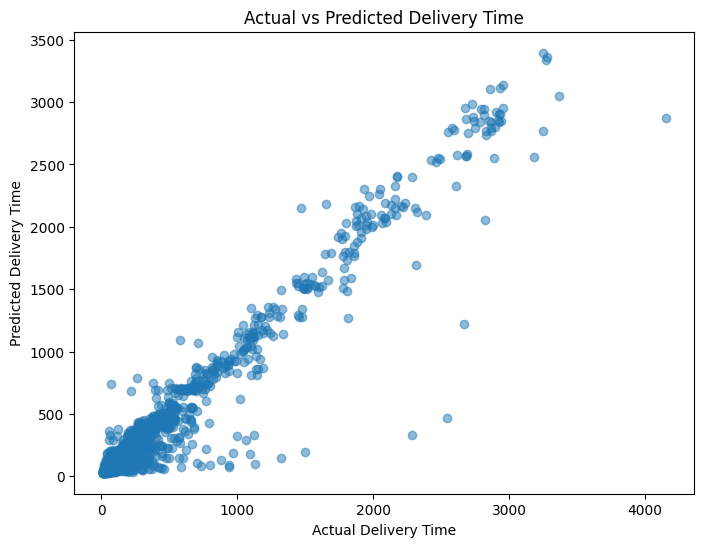

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison["Actual_Time"],
    comparison["Predicted_Time"],
    alpha=0.5
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [30]:
print(
    "STAGE 7b: Training final production model ..."
)

X_all = pd.concat(
    [Xtr, Xte],
    axis=0
)

y_all = pd.concat(
    [ytr, yte],
    axis=0
)

final_model = HistGradientBoostingRegressor(
    random_state=RNG,
    max_depth=8,
    learning_rate=0.08
)

final_model.fit(
    X_all,
    y_all
)

print("Final production model trained.")

STAGE 7b: Training final production model ...
Final production model trained.


In [31]:
print("STAGE 8: Creating operational reports ...")

node_feats.sort_values(
    "sla_breach_contribution",
    ascending=False
).to_csv(
    f"{ARTIFACT_DIR}/hub_bottleneck_ranking.csv",
    index=False
)

edge_stats[
    edge_stats["median_delay_ratio"] > 1.20
].sort_values(
    "sla_breach_rate",
    ascending=False
).to_csv(
    f"{ARTIFACT_DIR}/chronic_delay_corridors.csv",
    index=False
)

print("Operational reports created.")

STAGE 8: Creating operational reports ...
Operational reports created.


In [32]:
print("STAGE 9: Exporting deployment artifacts ...")

joblib.dump(
    final_model,
    f"{ARTIFACT_DIR}/eta_model.joblib"
)

print("Model saved.")

STAGE 9: Exporting deployment artifacts ...
Model saved.


In [33]:
node_feats.to_csv(
    f"{ARTIFACT_DIR}/node_features.csv",
    index=False
)

edge_stats.to_csv(
    f"{ARTIFACT_DIR}/corridor_stats.csv",
    index=False
)

print("Graph artifacts saved.")

Graph artifacts saved.


In [34]:
metadata = {
    "trained_at": datetime.utcnow().isoformat(),

    "n_hops_trained_on": int(
        len(hops)
    ),

    "graph_nodes": int(
        G.number_of_nodes()
    ),

    "graph_edges": int(
        G.number_of_edges()
    ),

    "held_out_mae_minutes": round(
        mae,
        2
    ),

    "held_out_within_15pct": round(
        within15,
        1
    ),

    "graph_feat_cols":
        GRAPH_FEAT_COLS,

    "base_feats":
        BASE_FEATS,

    "full_feature_order":
        GRAPH_FEATS,

    "default_node_row":
        DEFAULT_NODE_ROW,

    "default_corridor_delay_ratio":
        DEFAULT_CORRIDOR_DELAY,

    "sklearn_model_class":
        "HistGradientBoostingRegressor"
}

In [35]:
with open(
    f"{ARTIFACT_DIR}/metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

print("Metadata saved.")

Metadata saved.


In [36]:
print("Files created in artifacts:")

for file in os.listdir(ARTIFACT_DIR):
    print("✓", file)

Files created in artifacts:
✓ chronic_delay_corridors.csv
✓ corridor_stats.csv
✓ eta_model.joblib
✓ hub_bottleneck_ranking.csv
✓ metadata.json
✓ node_features.csv


In [37]:
loaded_model = joblib.load(
    f"{ARTIFACT_DIR}/eta_model.joblib"
)

print("Model loaded successfully.")

test_prediction = loaded_model.predict(
    Xte.iloc[:5]
)

print(test_prediction)

Model loaded successfully.
[53.70033658 47.24202003 47.20314445 34.92696181 41.72988564]


In [38]:
sample = Xte.iloc[[0]]

prediction = loaded_model.predict(
    sample
)[0]

print(
    f"Predicted actual delivery time: "
    f"{prediction:.2f} minutes"
)

print(
    f"Actual delivery time: "
    f"{yte.iloc[0]:.2f} minutes"
)

Predicted actual delivery time: 53.70 minutes
Actual delivery time: 51.00 minutes
